In [63]:
import pandas as pd
df=pd.read_csv("StudentsPerformance.csv")

In [64]:
#renaming for cleaning the spaces
df=df.rename(columns={"race/ethnicity":"ethnicity","parental level of education":"parental_level_of_education",
        "test preparation course":"test_preparation_course",
        "math score":"math_score","reading score":"reading_score","writing score":"writing_score"
})

In [65]:
#adding total score column
df['total_score']=df['math_score']+ df["reading_score"]+ df['writing_score']


In [66]:
#calculating average per student
df['average_score']=round(df['total_score']/3)


In [67]:
#adding perfomance column
df['performance']=df['average_score'].apply(lambda x: "Excellent" if x>=80 else "Good" if x>=60 else "Poor" )

In [68]:
#sorting by performance
classification=df.groupby('performance')['performance'].count()


In [69]:
#average by gender for subjects
avg_by_gender = round(df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean())
print(avg_by_gender)

        math_score  reading_score  writing_score
gender                                          
female        64.0           73.0           72.0
male          69.0           65.0           63.0


In [70]:
#highest average total score per parental education
highest_per_parental=df.groupby("parental_level_of_education")['average_score'].mean()
print(highest_per_parental.idxmax())

master's degree


In [71]:
#percentage of students with complete test prep course
df["test_preparation_course"]=df["test_preparation_course"].apply(lambda x: True if x=="completed" else False)
total_true=(df["test_preparation_course"].sum())*100/len(df["test_preparation_course"])
print(f"Percentage of students completed the test preparation course: {total_true}%")

Percentage of students completed the test preparation course: 35.8%


In [72]:
#checking if completed course helps with scores if true is >false average then yes
test_check=df.groupby('test_preparation_course')['average_score'].mean()
print(test_check)


test_preparation_course
False    65.024922
True     72.670391
Name: average_score, dtype: float64


In [73]:
#highest by race
highest_race=df.groupby("ethnicity")['average_score'].mean()
print(f"Highest ethnicity by average score: {highest_race.idxmax()}")

Highest ethnicity by average score: group E


In [76]:
#average per lunch program
avg_lunch=round(df.groupby("lunch")['average_score'].mean())
print(f"average score per lunch program: \n{avg_lunch}")

average score per lunch program: 
lunch
free/reduced    62.0
standard        71.0
Name: average_score, dtype: float64


In [75]:
#top 10 by total score
top_ten=df.nlargest(10,'total_score')
print(f"Top ten students: \n{top_ten}")

Top ten students: 
     gender ethnicity parental_level_of_education         lunch  \
458  female   group E           bachelor's degree      standard   
916    male   group E           bachelor's degree      standard   
962  female   group E          associate's degree      standard   
114  female   group E           bachelor's degree      standard   
179  female   group D            some high school      standard   
712  female   group D                some college      standard   
165  female   group C           bachelor's degree      standard   
625    male   group D                some college      standard   
149    male   group E          associate's degree  free/reduced   
685  female   group E             master's degree      standard   

     test_preparation_course  math_score  reading_score  writing_score  \
458                    False         100            100            100   
916                     True         100            100            100   
962                  

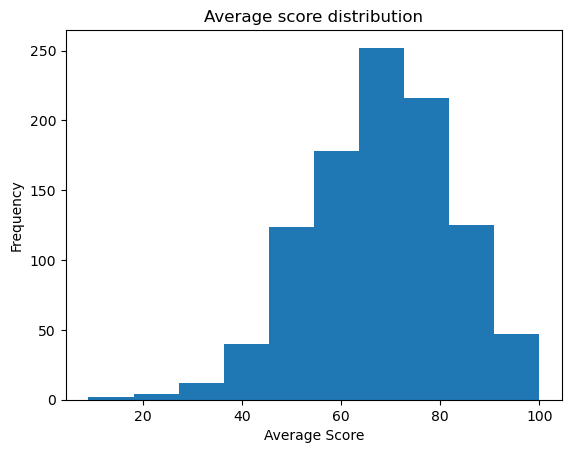

In [83]:
#data visualization
#histo of avg score distribution
import matplotlib.pyplot as plt
df['average_score'].plot(kind="hist",title="Average score distribution")
plt.xlabel('Average Score')
plt.show()

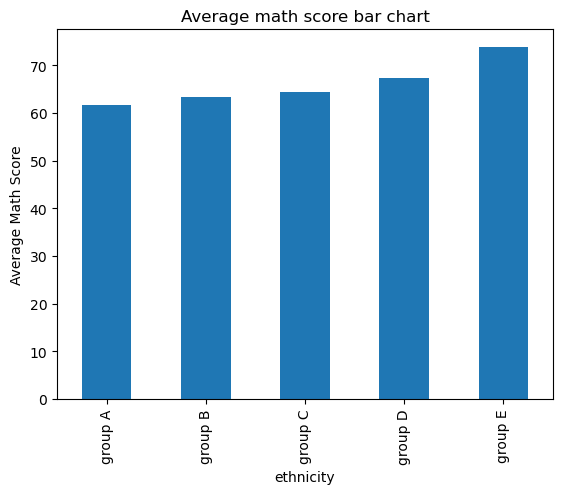

In [84]:
# bar chart of average math score by ethnicity
avg_math=df.groupby('ethnicity')["math_score"].mean()
bar_chart=avg_math.plot(kind="bar",title="Average math score bar chart")
plt.ylabel('Average Math Score')
plt.show()

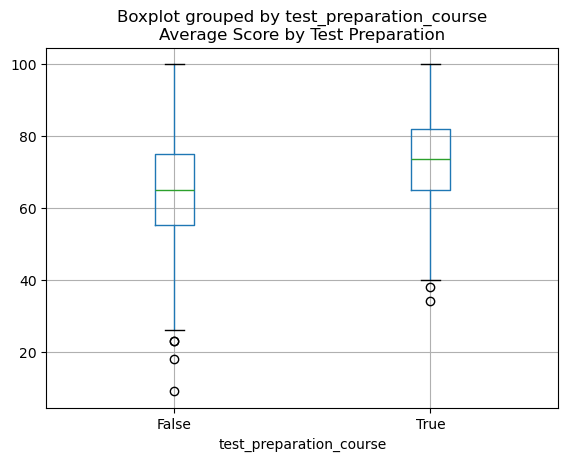

In [85]:
#box plot comparing average scores between test prep completed vs none
df
average_scores_per_test_course=df.groupby("test_preparation_course")['average_score'].apply(list)
df.boxplot(column='average_score', by='test_preparation_course')
plt.title('Average Score by Test Preparation')
plt.show()